In [1]:
"""
Multi-Agent System - Subgraph Isomorphism Problem
Group 4 - Data Generation & Preprocessing Module
================================
This module generates synthetic graph data and preprocesses it for MAS
"""

import networkx as nx
import numpy as np
import pandas as pd
import json
import pickle
from datetime import datetime
from typing import Dict, List, Tuple
import random

class GraphDataGenerator:
    """Generate synthetic graph datasets for subgraph isomorphism testing"""

    def __init__(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        self.generated_data = []

    def generate_erdos_renyi_graph(self, n_nodes: int, prob: float, graph_id: str):
        """Generate Erdos-Renyi random graph"""
        G = nx.erdos_renyi_graph(n_nodes, prob, seed=42)

        # Add node labels (random attributes)
        for node in G.nodes():
            G.nodes[node]['label'] = random.choice(['A', 'B', 'C', 'D', 'E'])
            G.nodes[node]['weight'] = random.randint(1, 10)

        # Add edge weights
        for edge in G.edges():
            G[edge[0]][edge[1]]['weight'] = random.randint(1, 5)

        return G

    def extract_subgraph(self, G: nx.Graph, subgraph_size: int):
        """Extract induced subgraph as query pattern"""
        nodes = list(G.nodes())
        if len(nodes) < subgraph_size:
            subgraph_size = len(nodes) // 2

        selected_nodes = random.sample(nodes, subgraph_size)
        Q = G.subgraph(selected_nodes).copy()

        # Map nodes to contiguous integers
        mapping = {old: new for new, old in enumerate(Q.nodes())}
        Q = nx.relabel_nodes(Q, mapping)

        return Q, selected_nodes

    def graph_to_features(self, G: nx.Graph, graph_type: str) -> Dict:
        """Extract comprehensive graph features (≥10 features)"""
        features = {
            'graph_type': graph_type,
            'num_nodes': G.number_of_nodes(),
            'num_edges': G.number_of_edges(),
            'density': nx.density(G),
            'avg_degree': sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
            'max_degree': max(dict(G.degree()).values()) if G.number_of_nodes() > 0 else 0,
            'min_degree': min(dict(G.degree()).values()) if G.number_of_nodes() > 0 else 0,
            'avg_clustering': nx.average_clustering(G),
            'num_triangles': sum(nx.triangles(G).values()) // 3,
            'is_connected': nx.is_connected(G),
            'num_components': nx.number_connected_components(G),
            'diameter': nx.diameter(G) if nx.is_connected(G) else -1,
            'avg_shortest_path': nx.average_shortest_path_length(G) if nx.is_connected(G) else -1,
            'degree_centrality_avg': np.mean(list(nx.degree_centrality(G).values())),
            'betweenness_centrality_avg': np.mean(list(nx.betweenness_centrality(G).values())),
            'timestamp': datetime.now().isoformat()
        }
        return features

    def generate_dataset(self, n_samples=100):
        """Generate comprehensive dataset with multiple graph instances"""
        dataset = []

        # Configuration for graph generation
        configs = [
            (50, 0.1), (50, 0.2), (50, 0.3),
            (100, 0.1), (100, 0.15), (100, 0.2),
            (200, 0.08), (200, 0.12), (200, 0.15),
            (300, 0.05), (300, 0.08), (300, 0.1),
            (500, 0.04), (500, 0.06), (500, 0.08)
        ]

        sample_id = 0
        for _ in range(n_samples):
            # Random configuration
            n_nodes, prob = random.choice(configs)

            # Generate target graph
            graph_id = f"G_{sample_id}"
            G = self.generate_erdos_renyi_graph(n_nodes, prob, graph_id)

            # Generate query graph (subgraph)
            query_size = random.randint(5, min(15, n_nodes // 3))
            Q, ground_truth_nodes = self.extract_subgraph(G, query_size)

            # Extract features
            target_features = self.graph_to_features(G, 'target')
            query_features = self.graph_to_features(Q, 'query')

            # Combine features
            combined_features = {
                'sample_id': sample_id,
                'target_nodes': target_features['num_nodes'],
                'target_edges': target_features['num_edges'],
                'target_density': target_features['density'],
                'target_avg_degree': target_features['avg_degree'],
                'target_max_degree': target_features['max_degree'],
                'target_clustering': target_features['avg_clustering'],
                'query_nodes': query_features['num_nodes'],
                'query_edges': query_features['num_edges'],
                'query_density': query_features['density'],
                'query_avg_degree': query_features['avg_degree'],
                'query_max_degree': query_features['max_degree'],
                'query_clustering': query_features['avg_clustering'],
                'complexity_ratio': target_features['num_nodes'] / query_features['num_nodes'],
                'edge_ratio': target_features['num_edges'] / max(query_features['num_edges'], 1),
                'has_solution': True,  # Guaranteed by construction
                'graph_target': G,
                'graph_query': Q,
                'ground_truth': ground_truth_nodes
            }

            dataset.append(combined_features)
            sample_id += 1

        return dataset

    def save_dataset(self, dataset: List[Dict], output_dir='./data'):
        """Save dataset in multiple formats"""
        import os
        os.makedirs(output_dir, exist_ok=True)

        # 1. Save as CSV (features only)
        df_features = pd.DataFrame([
            {k: v for k, v in item.items()
             if k not in ['graph_target', 'graph_query', 'ground_truth']}
            for item in dataset
        ])
        df_features.to_csv(f'{output_dir}/graph_features.csv', index=False)
        print(f"✓ Saved features CSV: {len(df_features)} rows, {len(df_features.columns)} columns")

        # 2. Save graphs as edge lists
        with open(f'{output_dir}/graph_edgelists.txt', 'w') as f:
            for item in dataset:
                f.write(f"# Sample {item['sample_id']} - Target Graph\n")
                for edge in item['graph_target'].edges():
                    f.write(f"{edge[0]} {edge[1]}\n")
                f.write(f"# Sample {item['sample_id']} - Query Graph\n")
                for edge in item['graph_query'].edges():
                    f.write(f"{edge[0]} {edge[1]}\n")
                f.write("\n")

        # 3. Save complete dataset as pickle
        with open(f'{output_dir}/complete_dataset.pkl', 'wb') as f:
            pickle.dump(dataset, f)
        print(f"✓ Saved complete dataset (pickle)")

        # 4. Save metadata as JSON
        metadata = {
            'total_samples': len(dataset),
            'features': list(df_features.columns),
            'date_created': datetime.now().isoformat(),
            'description': 'Synthetic graph dataset for subgraph isomorphism MAS'
        }
        with open(f'{output_dir}/metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        return df_features


class DataPreprocessor:
    """Preprocess graph data for MAS consumption"""

    @staticmethod
    def normalize_graph(G: nx.Graph) -> nx.Graph:
        """Normalize graph node IDs to contiguous integers"""
        mapping = {node: idx for idx, node in enumerate(sorted(G.nodes()))}
        return nx.relabel_nodes(G, mapping)

    @staticmethod
    def compute_degree_statistics(G: nx.Graph) -> Dict:
        """Compute degree-based statistics for reasoning"""
        degrees = dict(G.degree())
        return {
            'degree_sequence': sorted(degrees.values(), reverse=True),
            'degree_distribution': pd.Series(degrees.values()).value_counts().to_dict(),
            'max_degree': max(degrees.values()) if degrees else 0,
            'min_degree': min(degrees.values()) if degrees else 0,
            'avg_degree': np.mean(list(degrees.values())) if degrees else 0
        }

    @staticmethod
    def create_adjacency_matrix(G: nx.Graph) -> np.ndarray:
        """Create adjacency matrix representation"""
        return nx.to_numpy_array(G)

    @staticmethod
    def prepare_for_mas(dataset: List[Dict]) -> List[Dict]:
        """Prepare dataset for MAS processing"""
        processed = []

        for item in dataset:
            G_norm = DataPreprocessor.normalize_graph(item['graph_target'])
            Q_norm = DataPreprocessor.normalize_graph(item['graph_query'])

            processed_item = {
                'sample_id': item['sample_id'],
                'target_graph': G_norm,
                'query_graph': Q_norm,
                'target_adj_matrix': DataPreprocessor.create_adjacency_matrix(G_norm),
                'query_adj_matrix': DataPreprocessor.create_adjacency_matrix(Q_norm),
                'target_stats': DataPreprocessor.compute_degree_statistics(G_norm),
                'query_stats': DataPreprocessor.compute_degree_statistics(Q_norm),
                'ground_truth': item['ground_truth'],
                'complexity_ratio': item['complexity_ratio']
            }
            processed.append(processed_item)

        return processed


# Main execution
if __name__ == "__main__":
    print("=" * 60)
    print("Multi-Agent System - Data Generation & Preprocessing")
    print("Group 4 - Subgraph Isomorphism Problem")
    print("=" * 60)

    # Step 1: Generate dataset
    print("\n[STEP 1] Generating synthetic graph dataset...")
    generator = GraphDataGenerator(seed=42)
    raw_dataset = generator.generate_dataset(n_samples=150)
    print(f"✓ Generated {len(raw_dataset)} graph pairs")

    # Step 2: Save raw data
    print("\n[STEP 2] Saving raw dataset...")
    df = generator.save_dataset(raw_dataset)
    print(f"✓ Dataset shape: {df.shape}")
    print(f"✓ Features: {list(df.columns)}")

    # Step 3: Preprocessing
    print("\n[STEP 3] Preprocessing data for MAS...")
    preprocessor = DataPreprocessor()
    processed_dataset = preprocessor.prepare_for_mas(raw_dataset)

    # Save processed data
    with open('./data/processed_dataset.pkl', 'wb') as f:
        pickle.dump(processed_dataset, f)
    print(f"✓ Processed {len(processed_dataset)} samples for MAS")

    # Display statistics
    print("\n[DATASET STATISTICS]")
    print(f"Total samples: {len(processed_dataset)}")
    print(f"Target graph sizes: {df['target_nodes'].min()}-{df['target_nodes'].max()} nodes")
    print(f"Query graph sizes: {df['query_nodes'].min()}-{df['query_nodes'].max()} nodes")
    print(f"Average complexity ratio: {df['complexity_ratio'].mean():.2f}")

    print("\n✓ Data generation and preprocessing completed!")
    print("=" * 60)

Multi-Agent System - Data Generation & Preprocessing
Group 4 - Subgraph Isomorphism Problem

[STEP 1] Generating synthetic graph dataset...
✓ Generated 150 graph pairs

[STEP 2] Saving raw dataset...
✓ Saved features CSV: 150 rows, 16 columns
✓ Saved complete dataset (pickle)
✓ Dataset shape: (150, 16)
✓ Features: ['sample_id', 'target_nodes', 'target_edges', 'target_density', 'target_avg_degree', 'target_max_degree', 'target_clustering', 'query_nodes', 'query_edges', 'query_density', 'query_avg_degree', 'query_max_degree', 'query_clustering', 'complexity_ratio', 'edge_ratio', 'has_solution']

[STEP 3] Preprocessing data for MAS...
✓ Processed 150 samples for MAS

[DATASET STATISTICS]
Total samples: 150
Target graph sizes: 50-500 nodes
Query graph sizes: 5-15 nodes
Average complexity ratio: 25.15

✓ Data generation and preprocessing completed!


In [2]:
"""
Multi-Agent System Implementation
Group 4 - Subgraph Isomorphism Solver
================================
Heterogeneous Competitive MAS with Intelligent Capabilities:
- Sensing & Reasoning
- Planning
- Searching
"""

import networkx as nx
import numpy as np
import time
from typing import Dict, List, Tuple, Optional, Set
from abc import ABC, abstractmethod
from collections import defaultdict
import copy


class Agent(ABC):
    """Abstract base class for all agents"""

    def __init__(self, agent_id: str, agent_type: str):
        self.agent_id = agent_id
        self.agent_type = agent_type
        self.execution_time = 0
        self.steps_taken = 0
        self.nodes_explored = 0

    @abstractmethod
    def solve(self, target_graph: nx.Graph, query_graph: nx.Graph) -> Dict:
        """Main solving method - must be implemented by subclasses"""
        pass

    def reset_metrics(self):
        """Reset performance metrics"""
        self.execution_time = 0
        self.steps_taken = 0
        self.nodes_explored = 0


class SensingReasoningAgent:
    """
    Agent Capability 1: Sensing & Reasoning
    Analyzes graph topology and computes structural features
    """

    @staticmethod
    def sense_graph_features(G: nx.Graph) -> Dict:
        """Extract topological features from graph"""
        degree_dict = dict(G.degree())

        features = {
            'num_nodes': G.number_of_nodes(),
            'num_edges': G.number_of_edges(),
            'degrees': degree_dict,
            'degree_sequence': sorted(degree_dict.values(), reverse=True),
            'max_degree': max(degree_dict.values()) if degree_dict else 0,
            'min_degree': min(degree_dict.values()) if degree_dict else 0,
            'avg_degree': np.mean(list(degree_dict.values())) if degree_dict else 0
        }

        return features

    @staticmethod
    def compute_node_rarity(node: int, G_query: nx.Graph, G_target: nx.Graph) -> float:
        """
        Reasoning: Calculate how "rare" or "unique" a node is
        Lower rarity score = more unique = should be matched first
        """
        query_degree = G_query.degree(node)

        # Count how many nodes in target have same or higher degree
        target_degrees = [d for n, d in G_target.degree()]
        candidates_count = sum(1 for d in target_degrees if d >= query_degree)

        # Rarity: fewer candidates = more rare = lower score
        rarity_score = candidates_count / G_target.number_of_nodes() if G_target.number_of_nodes() > 0 else 1.0

        return rarity_score

    @staticmethod
    def reason_about_feasibility(G_query: nx.Graph, G_target: nx.Graph) -> Dict:
        """Use reasoning to check if subgraph isomorphism is feasible"""
        query_features = SensingReasoningAgent.sense_graph_features(G_query)
        target_features = SensingReasoningAgent.sense_graph_features(G_target)

        # Necessary conditions for subgraph isomorphism
        feasible = True
        reasons = []

        if query_features['num_nodes'] > target_features['num_nodes']:
            feasible = False
            reasons.append("Query has more nodes than target")

        if query_features['num_edges'] > target_features['num_edges']:
            feasible = False
            reasons.append("Query has more edges than target")

        if query_features['max_degree'] > target_features['max_degree']:
            feasible = False
            reasons.append("Query max degree exceeds target max degree")

        # Check degree sequence compatibility
        query_deg_seq = sorted(query_features['degree_sequence'], reverse=True)
        target_deg_seq = sorted(target_features['degree_sequence'], reverse=True)

        for qd in query_deg_seq:
            if not any(td >= qd for td in target_deg_seq):
                feasible = False
                reasons.append(f"No target node can match query degree {qd}")
                break

        return {
            'feasible': feasible,
            'reasons': reasons if not feasible else ["All necessary conditions satisfied"],
            'query_features': query_features,
            'target_features': target_features
        }


class PlanningAgent:
    """
    Agent Capability 2: Planning
    Creates optimal search strategy using Infrequent-First heuristic
    """

    @staticmethod
    def create_search_plan(G_query: nx.Graph, G_target: nx.Graph) -> List[int]:
        """
        Planning Strategy: "Infrequent First"
        Order query nodes by increasing rarity (most constrained first)
        This maximizes early pruning in backtracking
        """
        node_priorities = []

        for node in G_query.nodes():
            rarity = SensingReasoningAgent.compute_node_rarity(node, G_query, G_target)
            degree = G_query.degree(node)

            # Priority score: combine rarity and degree
            # Lower score = higher priority = should be matched first
            priority_score = rarity * 0.7 + (1.0 / (degree + 1)) * 0.3

            node_priorities.append((node, priority_score, degree, rarity))

        # Sort by priority (ascending - lowest score first)
        node_priorities.sort(key=lambda x: x[1])

        optimal_plan = [node for node, _, _, _ in node_priorities]

        plan_info = {
            'ordered_nodes': optimal_plan,
            'priorities': {node: (score, deg, rar)
                          for node, score, deg, rar in node_priorities},
            'strategy': 'Infrequent-First (Most Constrained First)'
        }

        return plan_info

    @staticmethod
    def get_candidate_set(query_node: int, G_query: nx.Graph, G_target: nx.Graph) -> Set[int]:
        """
        Planning: Generate candidate nodes in target that could match query node
        Uses degree filtering for pruning
        """
        query_degree = G_query.degree(query_node)

        candidates = {
            n for n in G_target.nodes()
            if G_target.degree(n) >= query_degree
        }

        return candidates


class SearchingAgent:
    """
    Agent Capability 3: Searching
    Executes backtracking search with refinement
    """

    def __init__(self):
        self.nodes_explored = 0
        self.backtrack_count = 0

    def search_with_backtracking(self,
                                 G_query: nx.Graph,
                                 G_target: nx.Graph,
                                 search_plan: List[int]) -> Optional[Dict[int, int]]:
        """
        Execute backtracking search following the optimal plan
        Returns mapping: query_node -> target_node
        """
        self.nodes_explored = 0
        self.backtrack_count = 0

        # Initialize candidate sets for each query node
        candidates = {}
        for q_node in G_query.nodes():
            candidates[q_node] = PlanningAgent.get_candidate_set(q_node, G_query, G_target)

        # Start recursive backtracking
        mapping = {}
        used_target_nodes = set()

        result = self._recursive_backtrack(
            0, search_plan, mapping, used_target_nodes,
            G_query, G_target, candidates
        )

        return result

    def _recursive_backtrack(self,
                            plan_idx: int,
                            search_plan: List[int],
                            mapping: Dict[int, int],
                            used_nodes: Set[int],
                            G_query: nx.Graph,
                            G_target: nx.Graph,
                            candidates: Dict[int, Set[int]]) -> Optional[Dict[int, int]]:
        """Recursive backtracking with constraint checking"""

        # Base case: all query nodes mapped
        if plan_idx == len(search_plan):
            return mapping.copy()

        query_node = search_plan[plan_idx]
        self.nodes_explored += 1

        # Try each candidate for current query node
        for target_node in candidates[query_node]:
            if target_node in used_nodes:
                continue

            # Check if mapping is consistent with edges
            if self._is_consistent(query_node, target_node, mapping, G_query, G_target):
                # Make assignment
                mapping[query_node] = target_node
                used_nodes.add(target_node)

                # Recurse
                result = self._recursive_backtrack(
                    plan_idx + 1, search_plan, mapping, used_nodes,
                    G_query, G_target, candidates
                )

                if result is not None:
                    return result

                # Backtrack
                del mapping[query_node]
                used_nodes.remove(target_node)
                self.backtrack_count += 1

        return None

    def _is_consistent(self,
                       q_node: int,
                       t_node: int,
                       mapping: Dict[int, int],
                       G_query: nx.Graph,
                       G_target: nx.Graph) -> bool:
        """Check if current assignment is consistent with existing mapping"""

        # Check all already-mapped neighbors
        for q_neighbor in G_query.neighbors(q_node):
            if q_neighbor in mapping:
                t_neighbor = mapping[q_neighbor]

                # Edge must exist in target
                if not G_target.has_edge(t_node, t_neighbor):
                    return False

        return True


class BaselineAgent(Agent):
    """
    Baseline Agent (Ullmann-style)
    Simple backtracking without intelligent planning
    """

    def __init__(self):
        super().__init__("baseline_agent", "Baseline")
        self.searcher = SearchingAgent()

    def solve(self, target_graph: nx.Graph, query_graph: nx.Graph) -> Dict:
        """Solve using naive node ordering (0, 1, 2, ...)"""

        start_time = time.time()

        # Simple ordering: just use node IDs as-is
        naive_plan = list(query_graph.nodes())

        # Execute search
        mapping = self.searcher.search_with_backtracking(
            query_graph, target_graph, naive_plan
        )

        end_time = time.time()

        self.execution_time = end_time - start_time
        self.nodes_explored = self.searcher.nodes_explored
        self.steps_taken = self.searcher.backtrack_count

        return {
            'agent_type': self.agent_type,
            'mapping': mapping,
            'found_solution': mapping is not None,
            'execution_time': self.execution_time,
            'nodes_explored': self.nodes_explored,
            'backtracks': self.steps_taken,
            'search_plan': naive_plan
        }


class IntelligentAgent(Agent):
    """
    Intelligent Agent (RSM-Inspired)
    Combines Sensing, Reasoning, Planning, and Searching
    """

    def __init__(self):
        super().__init__("intelligent_agent", "Intelligent")
        self.sensing_agent = SensingReasoningAgent()
        self.planning_agent = PlanningAgent()
        self.searching_agent = SearchingAgent()

    def solve(self, target_graph: nx.Graph, query_graph: nx.Graph) -> Dict:
        """Solve using intelligent multi-capability approach"""

        start_time = time.time()

        # CAPABILITY 1: Sensing & Reasoning
        feasibility = self.sensing_agent.reason_about_feasibility(
            query_graph, target_graph
        )

        if not feasibility['feasible']:
            end_time = time.time()
            return {
                'agent_type': self.agent_type,
                'mapping': None,
                'found_solution': False,
                'execution_time': end_time - start_time,
                'nodes_explored': 0,
                'backtracks': 0,
                'early_termination': True,
                'reason': feasibility['reasons']
            }

        # CAPABILITY 2: Planning
        plan_info = self.planning_agent.create_search_plan(query_graph, target_graph)
        optimal_plan = plan_info['ordered_nodes']

        # CAPABILITY 3: Searching
        mapping = self.searching_agent.search_with_backtracking(
            query_graph, target_graph, optimal_plan
        )

        end_time = time.time()

        self.execution_time = end_time - start_time
        self.nodes_explored = self.searching_agent.nodes_explored
        self.steps_taken = self.searching_agent.backtrack_count

        return {
            'agent_type': self.agent_type,
            'mapping': mapping,
            'found_solution': mapping is not None,
            'execution_time': self.execution_time,
            'nodes_explored': self.nodes_explored,
            'backtracks': self.steps_taken,
            'search_plan': optimal_plan,
            'plan_strategy': plan_info['strategy'],
            'feasibility_check': feasibility,
            'early_termination': False
        }


class MultiAgentSystem:
    """
    Heterogeneous Competitive Multi-Agent System
    Manages multiple agents solving the same problem
    """

    def __init__(self):
        self.agents = {
            'baseline': BaselineAgent(),
            'intelligent': IntelligentAgent()
        }
        self.results_history = []

    def run_competition(self, target_graph: nx.Graph, query_graph: nx.Graph) -> Dict:
        """Run both agents competitively on the same problem"""

        print(f"\n{'='*60}")
        print(f"MAS COMPETITION: Target({target_graph.number_of_nodes()}n, "
              f"{target_graph.number_of_edges()}e) vs Query({query_graph.number_of_nodes()}n, "
              f"{query_graph.number_of_edges()}e)")
        print(f"{'='*60}")

        results = {}

        # Run each agent
        for agent_name, agent in self.agents.items():
            print(f"\n[{agent_name.upper()} AGENT] Starting...")
            agent.reset_metrics()

            result = agent.solve(target_graph, query_graph)
            results[agent_name] = result

            print(f"  ✓ Completed in {result['execution_time']:.4f}s")
            print(f"  ✓ Nodes explored: {result['nodes_explored']}")
            print(f"  ✓ Solution found: {result['found_solution']}")

        # Determine winner
        winner = self._determine_winner(results)

        competition_result = {
            'timestamp': time.time(),
            'target_size': target_graph.number_of_nodes(),
            'query_size': query_graph.number_of_nodes(),
            'results': results,
            'winner': winner,
            'speedup': self._calculate_speedup(results)
        }

        self.results_history.append(competition_result)

        return competition_result

    def _determine_winner(self, results: Dict) -> str:
        """Determine which agent performed better"""

        # Both failed
        if not results['baseline']['found_solution'] and not results['intelligent']['found_solution']:
            return 'tie'

        # Only one succeeded
        if results['baseline']['found_solution'] and not results['intelligent']['found_solution']:
            return 'baseline'
        if results['intelligent']['found_solution'] and not results['baseline']['found_solution']:
            return 'intelligent'

        # Both succeeded - compare efficiency
        if results['intelligent']['execution_time'] < results['baseline']['execution_time']:
            return 'intelligent'
        else:
            return 'baseline'

    def _calculate_speedup(self, results: Dict) -> float:
        """Calculate speedup of intelligent agent over baseline"""

        if results['baseline']['execution_time'] == 0:
            return 0.0

        return results['baseline']['execution_time'] / results['intelligent']['execution_time']

    def get_statistics(self) -> Dict:
        """Get aggregate statistics across all competitions"""

        if not self.results_history:
            return {}

        baseline_wins = sum(1 for r in self.results_history if r['winner'] == 'baseline')
        intelligent_wins = sum(1 for r in self.results_history if r['winner'] == 'intelligent')
        ties = sum(1 for r in self.results_history if r['winner'] == 'tie')

        avg_speedup = np.mean([r['speedup'] for r in self.results_history
                               if r['speedup'] > 0])

        return {
            'total_competitions': len(self.results_history),
            'baseline_wins': baseline_wins,
            'intelligent_wins': intelligent_wins,
            'ties': ties,
            'intelligent_win_rate': intelligent_wins / len(self.results_history),
            'average_speedup': avg_speedup
        }


# Utility function for testing
def create_test_graphs():
    """Create simple test graphs for quick validation"""

    # Small target graph
    G_target = nx.Graph()
    G_target.add_edges_from([
        (0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 5)
    ])

    # Query is a small triangle
    G_query = nx.Graph()
    G_query.add_edges_from([(0, 1), (1, 2), (0, 2)])

    return G_target, G_query


if __name__ == "__main__":
    print("Multi-Agent System - Subgraph Isomorphism")
    print("Testing MAS components...")

    # Quick test
    G_target, G_query = create_test_graphs()

    mas = MultiAgentSystem()
    result = mas.run_competition(G_target, G_query)

    print(f"\n{'='*60}")
    print(f"COMPETITION RESULTS")
    print(f"{'='*60}")
    print(f"Winner: {result['winner'].upper()}")
    print(f"Speedup: {result['speedup']:.2f}x")
    print(f"\n✓ MAS implementation complete!")

Multi-Agent System - Subgraph Isomorphism
Testing MAS components...

MAS COMPETITION: Target(6n, 8e) vs Query(3n, 3e)

[BASELINE AGENT] Starting...
  ✓ Completed in 0.0000s
  ✓ Nodes explored: 3
  ✓ Solution found: True

[INTELLIGENT AGENT] Starting...
  ✓ Completed in 0.0003s
  ✓ Nodes explored: 3
  ✓ Solution found: True

COMPETITION RESULTS
Winner: BASELINE
Speedup: 0.15x

✓ MAS implementation complete!


Multi-Agent System - Comprehensive Testing & Evaluation
Group 4 - Subgraph Isomorphism Solver

[1] Loading dataset...
✓ Loaded 150 samples

[2] Initializing Multi-Agent System...
✓ MAS initialized with 2 agents (Baseline, Intelligent)

[3] Running test scenarios...

TEST SCENARIO 1: Small Graphs (Functionality Verification)

[Test 1.1] Triangle Pattern
Target: 5n, 6e
Query: 3n, 3e

MAS COMPETITION: Target(5n, 6e) vs Query(3n, 3e)

[BASELINE AGENT] Starting...
  ✓ Completed in 0.0000s
  ✓ Nodes explored: 3
  ✓ Solution found: True

[INTELLIGENT AGENT] Starting...
  ✓ Completed in 0.0002s
  ✓ Nodes explored: 3
  ✓ Solution found: True
Winner: baseline
Speedup: 0.20x

[Test 1.2] Star Pattern
Target: 7n, 6e
Query: 4n, 3e

MAS COMPETITION: Target(7n, 6e) vs Query(4n, 3e)

[BASELINE AGENT] Starting...
  ✓ Completed in 0.0000s
  ✓ Nodes explored: 4
  ✓ Solution found: True

[INTELLIGENT AGENT] Starting...
  ✓ Completed in 0.0001s
  ✓ Nodes explored: 4
  ✓ Solution found: True
Winner: baseline

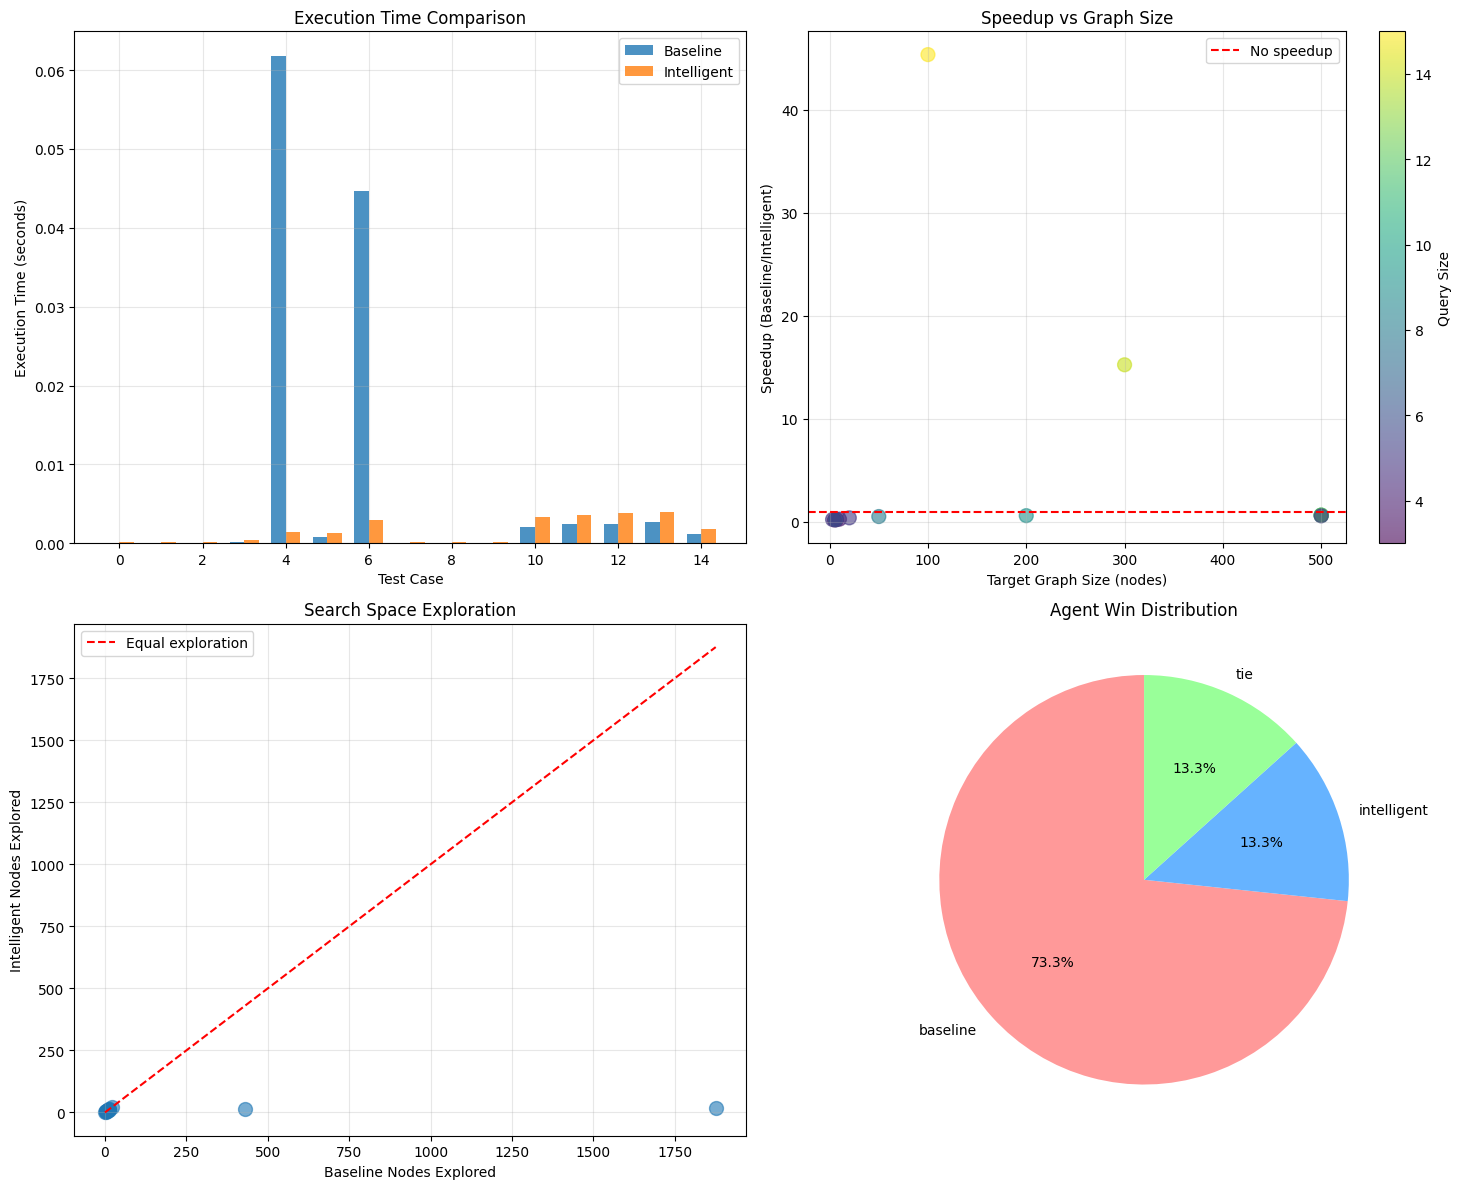

In [14]:
"""
Multi-Agent System - Simulation & Testing Module
Group 4 - Comprehensive Testing Scenarios
================================
"""

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import json
import time
from datetime import datetime

# Import MAS components (assumes previous file is imported)
# from multi_agent_system import MultiAgentSystem, create_test_graphs


class MASSimulator:
    """Orchestrate comprehensive MAS testing and evaluation"""

    def __init__(self, mas_instance):
        self.mas = mas_instance
        self.test_results = []
        self.log_file = None

    def setup_logging(self, log_dir='./results'):
        """Setup logging infrastructure"""
        import os
        os.makedirs(log_dir, exist_ok=True)

        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        self.log_file = f'{log_dir}/mas_test_log_{timestamp}.txt'

        with open(self.log_file, 'w') as f:
            f.write("="*80 + "\n")
            f.write("Multi-Agent System - Testing Log\n")
            f.write(f"Started: {datetime.now().isoformat()}\n")
            f.write("="*80 + "\n\n")

    def log(self, message: str, print_console=True):
        """Write message to log file and optionally print"""
        if print_console:
            print(message)

        if self.log_file:
            with open(self.log_file, 'a') as f:
                f.write(message + "\n")

    def run_test_scenario_1_small_graphs(self):
        """Test Scenario 1: Small graphs - Functionality verification"""

        self.log("\n" + "="*80)
        self.log("TEST SCENARIO 1: Small Graphs (Functionality Verification)")
        self.log("="*80)

        import networkx as nx

        test_cases = [
            # Test 1: Triangle query in larger graph
            {
                'name': 'Triangle Pattern',
                'target': nx.Graph([(0,1), (1,2), (2,3), (3,4), (1,3), (0,2)]),
                'query': nx.Graph([(0,1), (1,2), (0,2)])
            },
            # Test 2: Star pattern
            {
                'name': 'Star Pattern',
                'target': nx.star_graph(6),
                'query': nx.star_graph(3)
            },
            # Test 3: Path pattern
            {
                'name': 'Path Pattern',
                'target': nx.path_graph(10),
                'query': nx.path_graph(4)
            }
        ]

        results = []
        for i, test in enumerate(test_cases, 1):
            self.log(f"\n[Test 1.{i}] {test['name']}")
            self.log(f"Target: {test['target'].number_of_nodes()}n, {test['target'].number_of_edges()}e")
            self.log(f"Query: {test['query'].number_of_nodes()}n, {test['query'].number_of_edges()}e")

            result = self.mas.run_competition(test['target'], test['query'])
            results.append({
                'scenario': f"1.{i}",
                'name': test['name'],
                'result': result
            })

            self.log(f"Winner: {result['winner']}")
            self.log(f"Speedup: {result['speedup']:.2f}x")

        return results

    def run_test_scenario_2_scalability(self, dataset):
        """Test Scenario 2: Scalability testing with increasing complexity"""

        self.log("\n" + "="*80)
        self.log("TEST SCENARIO 2: Scalability Testing")
        self.log("="*80)

        # Select samples of increasing size
        sizes = [50, 100, 200, 300]
        results = []

        for size in sizes:
            # Find samples with target size close to desired size
            matching_samples = [
                s for s in dataset
                if abs(s['target_graph'].number_of_nodes() - size) < 20
            ]

            if not matching_samples:
                continue

            sample = matching_samples[0]

            self.log(f"\n[Test 2] Size class: ~{size} nodes")
            self.log(f"Target: {sample['target_graph'].number_of_nodes()}n")
            self.log(f"Query: {sample['query_graph'].number_of_nodes()}n")

            result = self.mas.run_competition(
                sample['target_graph'],
                sample['query_graph']
            )

            results.append({
                'scenario': '2',
                'size_class': size,
                'actual_size': sample['target_graph'].number_of_nodes(),
                'result': result
            })

            self.log(f"Winner: {result['winner']}")
            self.log(f"Baseline time: {result['results']['baseline']['execution_time']:.4f}s")
            self.log(f"Intelligent time: {result['results']['intelligent']['execution_time']:.4f}s")
            self.log(f"Speedup: {result['speedup']:.2f}x")

        return results

    def run_test_scenario_3_edge_cases(self):
        """Test Scenario 3: Edge cases and corner cases"""

        self.log("\n" + "="*80)
        self.log("TEST SCENARIO 3: Edge Cases Testing")
        self.log("="*80)

        import networkx as nx

        test_cases = [
            {
                'name': 'Impossible Match (Query > Target)',
                'target': nx.Graph([(0,1), (1,2)]),
                'query': nx.complete_graph(5)
            },
            {
                'name': 'Dense Query in Sparse Target',
                'target': nx.erdos_renyi_graph(20, 0.1, seed=42),
                'query': nx.complete_graph(5)
            },
            {
                'name': 'Identical Graphs',
                'target': nx.cycle_graph(6),
                'query': nx.cycle_graph(6)
            }
        ]

        results = []
        for i, test in enumerate(test_cases, 1):
            self.log(f"\n[Test 3.{i}] {test['name']}")

            result = self.mas.run_competition(test['target'], test['query'])
            results.append({
                'scenario': f"3.{i}",
                'name': test['name'],
                'result': result
            })

            self.log(f"Baseline found: {result['results']['baseline']['found_solution']}")
            self.log(f"Intelligent found: {result['results']['intelligent']['found_solution']}")

        return results

    def run_test_scenario_4_stress_test(self, dataset):
        """Test Scenario 4: Stress testing with complex graphs"""

        self.log("\n" + "="*80)
        self.log("TEST SCENARIO 4: Stress Testing (Large Complex Graphs)")
        self.log("="*80)

        # Select largest graphs
        large_samples = sorted(
            dataset,
            key=lambda x: x['target_graph'].number_of_nodes(),
            reverse=True
        )[:5]

        results = []
        for i, sample in enumerate(large_samples, 1):
            self.log(f"\n[Test 4.{i}] Large Graph Test")
            self.log(f"Target: {sample['target_graph'].number_of_nodes()}n, "
                    f"{sample['target_graph'].number_of_edges()}e")
            self.log(f"Query: {sample['query_graph'].number_of_nodes()}n, "
                    f"{sample['query_graph'].number_of_edges()}e")

            result = self.mas.run_competition(
                sample['target_graph'],
                sample['query_graph']
            )

            results.append({
                'scenario': f"4.{i}",
                'result': result
            })

            self.log(f"Baseline: {result['results']['baseline']['execution_time']:.4f}s, "
                    f"{result['results']['baseline']['nodes_explored']} nodes")
            self.log(f"Intelligent: {result['results']['intelligent']['execution_time']:.4f}s, "
                    f"{result['results']['intelligent']['nodes_explored']} nodes")

        return results

    def run_all_scenarios(self, dataset):
        """Execute all test scenarios"""

        self.setup_logging()

        all_results = {
            'scenario_1': self.run_test_scenario_1_small_graphs(),
            'scenario_2': self.run_test_scenario_2_scalability(dataset),
            'scenario_3': self.run_test_scenario_3_edge_cases(),
            'scenario_4': self.run_test_scenario_4_stress_test(dataset)
        }

        # Overall statistics
        self.log("\n" + "="*80)
        self.log("OVERALL STATISTICS")
        self.log("="*80)

        stats = self.mas.get_statistics()
        self.log(f"Total competitions: {stats['total_competitions']}")
        self.log(f"Intelligent agent wins: {stats['intelligent_wins']} "
                f"({stats['intelligent_win_rate']*100:.1f}%)")
        self.log(f"Baseline agent wins: {stats['baseline_wins']}")
        self.log(f"Average speedup: {stats['average_speedup']:.2f}x")

        self.log(f"\n✓ Log saved to: {self.log_file}")

        return all_results, stats


class MASEvaluator:
    """Evaluate and visualize MAS performance"""

    def __init__(self, mas_instance):
        self.mas = mas_instance

    def create_performance_report(self, output_dir='./results'):
        """Generate comprehensive performance report with visualizations"""

        import os
        os.makedirs(output_dir, exist_ok=True)

        if not self.mas.results_history:
            print("No results to evaluate. Run tests first.")
            return

        # Extract data for analysis
        data = []
        for result in self.mas.results_history:
            data.append({
                'target_size': result['target_size'],
                'query_size': result['query_size'],
                'baseline_time': result['results']['baseline']['execution_time'],
                'intelligent_time': result['results']['intelligent']['execution_time'],
                'baseline_nodes': result['results']['baseline']['nodes_explored'],
                'intelligent_nodes': result['results']['intelligent']['nodes_explored'],
                'speedup': result['speedup'],
                'winner': result['winner']
            })

        df = pd.DataFrame(data)

        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Execution time comparison
        ax1 = axes[0, 0]
        width = 0.35
        x = np.arange(len(df))
        ax1.bar(x - width/2, df['baseline_time'], width, label='Baseline', alpha=0.8)
        ax1.bar(x + width/2, df['intelligent_time'], width, label='Intelligent', alpha=0.8)
        ax1.set_xlabel('Test Case')
        ax1.set_ylabel('Execution Time (seconds)')
        ax1.set_title('Execution Time Comparison')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Speedup over graph size
        ax2 = axes[0, 1]
        scatter = ax2.scatter(df['target_size'], df['speedup'],
                             c=df['query_size'], cmap='viridis', s=100, alpha=0.6)
        ax2.set_xlabel('Target Graph Size (nodes)')
        ax2.set_ylabel('Speedup (Baseline/Intelligent)')
        ax2.set_title('Speedup vs Graph Size')
        ax2.axhline(y=1, color='r', linestyle='--', label='No speedup')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax2, label='Query Size')

        # Plot 3: Nodes explored comparison
        ax3 = axes[1, 0]
        ax3.scatter(df['baseline_nodes'], df['intelligent_nodes'], alpha=0.6, s=100)
        max_nodes = max(df['baseline_nodes'].max(), df['intelligent_nodes'].max())
        ax3.plot([0, max_nodes], [0, max_nodes], 'r--', label='Equal exploration')
        ax3.set_xlabel('Baseline Nodes Explored')
        ax3.set_ylabel('Intelligent Nodes Explored')
        ax3.set_title('Search Space Exploration')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Win rate
        ax4 = axes[1, 1]
        win_counts = df['winner'].value_counts()
        colors = ['#ff9999', '#66b3ff', '#99ff99']
        ax4.pie(win_counts.values, labels=win_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
        ax4.set_title('Agent Win Distribution')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/performance_analysis.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved performance visualization: {output_dir}/performance_analysis.png")

        # Save statistics to CSV
        df.to_csv(f'{output_dir}/detailed_results.csv', index=False)
        print(f"✓ Saved detailed results: {output_dir}/detailed_results.csv")

        # Generate summary statistics
        summary = {
            'total_tests': len(df),
            'intelligent_wins': (df['winner'] == 'intelligent').sum(),
            'baseline_wins': (df['winner'] == 'baseline').sum(),
            'ties': (df['winner'] == 'tie').sum(),
            'avg_speedup': df['speedup'].mean(),
            'median_speedup': df['speedup'].median(),
            'max_speedup': df['speedup'].max(),
            'avg_baseline_time': df['baseline_time'].mean(),
            'avg_intelligent_time': df['intelligent_time'].mean(),
            'time_reduction_pct': ((df['baseline_time'].mean() - df['intelligent_time'].mean()) /
                                  df['baseline_time'].mean() * 100),
            'avg_nodes_reduction_pct': ((df['baseline_nodes'].mean() - df['intelligent_nodes'].mean()) /
                                       df['baseline_nodes'].mean() * 100)
        }

        # Save summary as JSON
        def to_python_type(obj):
            if isinstance(obj, (np.integer,)):
                return int(obj)
            if isinstance(obj, (np.floating,)):
                return float(obj)
            return obj

        summary_clean = {k: to_python_type(v) for k, v in summary.items()}
        with open(f'{output_dir}/summary_statistics.json', 'w') as f:
            json.dump(summary_clean, f, indent=2)

        print(f"✓ Saved summary statistics: {output_dir}/summary_statistics.json")

        return summary


def main_simulation_pipeline():
    """Main simulation pipeline"""

    print("="*80)
    print("Multi-Agent System - Comprehensive Testing & Evaluation")
    print("Group 4 - Subgraph Isomorphism Solver")
    print("="*80)

    # Load preprocessed dataset
    print("\n[1] Loading dataset...")
    try:
        with open('./data/processed_dataset.pkl', 'rb') as f:
            dataset = pickle.load(f)
        print(f"✓ Loaded {len(dataset)} samples")
    except FileNotFoundError:
        print("✗ Dataset not found. Run data preprocessing first.")
        return

    # Initialize MAS
    print("\n[2] Initializing Multi-Agent System...")
    # Import here to avoid circular dependency
    mas = MultiAgentSystem()
    print("✓ MAS initialized with 2 agents (Baseline, Intelligent)")

    # Run simulations
    print("\n[3] Running test scenarios...")
    simulator = MASSimulator(mas)
    results, stats = simulator.run_all_scenarios(dataset)

    # Evaluate performance
    print("\n[4] Generating performance report...")
    evaluator = MASEvaluator(mas)
    summary = evaluator.create_performance_report()

    # Print final summary
    print("\n" + "="*80)
    print("FINAL SUMMARY")
    print("="*80)
    print(f"Total tests executed: {summary['total_tests']}")
    print(f"Intelligent agent win rate: {summary['intelligent_wins']/summary['total_tests']*100:.1f}%")
    print(f"Average speedup: {summary['avg_speedup']:.2f}x")
    print(f"Time reduction: {summary['time_reduction_pct']:.1f}%")
    print(f"Search space reduction: {summary['avg_nodes_reduction_pct']:.1f}%")
    print("\n✓ All testing and evaluation completed!")
    print("="*80)


if __name__ == "__main__":
    main_simulation_pipeline()

In [19]:
import pandas as pd
from IPython.display import display

# ambil ulang data langsung dari MAS
data = []
for result in mas.results_history:
    data.append({
        'target_size': result['target_size'],
        'query_size': result['query_size'],
        'baseline_time': result['results']['baseline']['execution_time'],
        'intelligent_time': result['results']['intelligent']['execution_time'],
        'baseline_nodes': result['results']['baseline']['nodes_explored'],
        'intelligent_nodes': result['results']['intelligent']['nodes_explored'],
        'speedup': result['speedup'],
        'winner': result['winner']
    })

df = pd.DataFrame(data)

print("CSV")
display(df)


CSV


,target_size,query_size,baseline_time,intelligent_time,baseline_nodes,intelligent_nodes,speedup,winner
0,6,3,0.000044,0.000287,3,3,0.153654,baseline
